In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
def sim_pulse(f_d,A,evolution,dim,f_rabi,K=20,t_ramp=10):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_edge=int(t_ramp*2/dt) #Määritellään reunojen pituudeksi 2x rampin pituus, jotta amplitudi menee lähemmäs nollaa
    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge],time_unit=dt,drag=True)
    U_floquet=evolution.U_floquet(A*pulse.raw[N_edge:N_edge+K],dt)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*pulse.raw[i], dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/K)+1

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse = pulses.Pulse(f_d,f_ef,[pulses.gaussian(t_ramp*2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,K*k,N_edge],time_unit=dt,drag=True)
        for i in range(0, N_edge): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*pulse.raw[N_edge+K*k+i], dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(q,A,evolution,f_rabi,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]

    f_d = q.frequency #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        sim_vals = sim_pulse(f_d+i/scale,A,evolution,dim,f_rabi)
        AC_stark_vals.append(i/scale)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=f_d-f_q (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

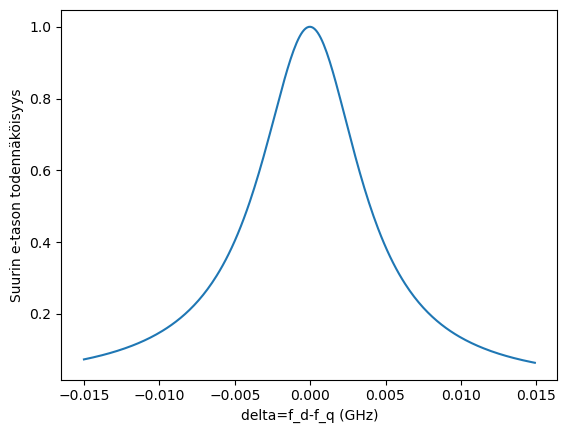

Amplitudi (GHz): 0.00405663690363797
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999721629125684
Pulssin pituus (ns): 765.1396009741865
Rabi-taajuus (fourier):  0.0006455692586171219


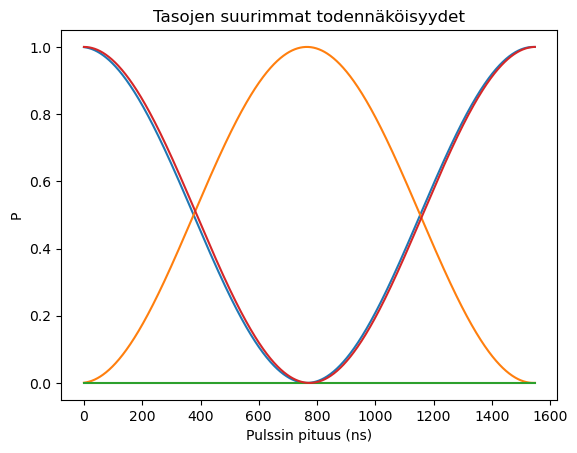

---------------------------------------------


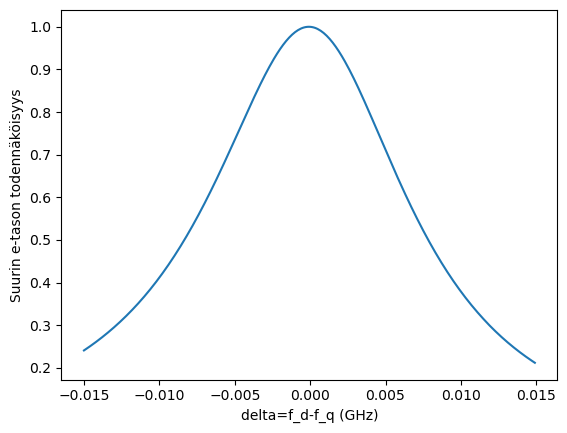

Amplitudi (GHz): 0.00811327380727594
AC-stark siirtymä (GHz): -0.0001
E-tason suurin todennäköisyys: 0.999996613059079
Pulssin pituus (ns): 376.3836163490506
Rabi-taajuus (fourier):  0.001291235800097349


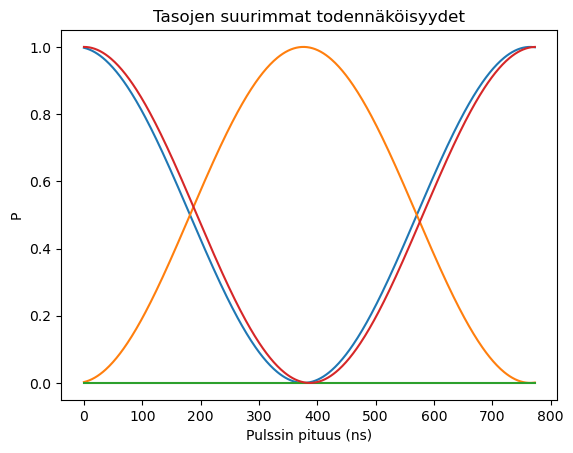

---------------------------------------------


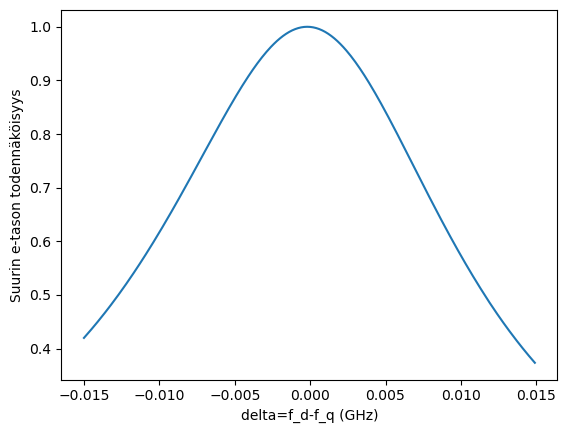

Amplitudi (GHz): 0.01216991071091391
AC-stark siirtymä (GHz): -0.0002
E-tason suurin todennäköisyys: 0.9999994797567014
Pulssin pituus (ns): 246.28177081852022
Rabi-taajuus (fourier):  0.0019364186699291099


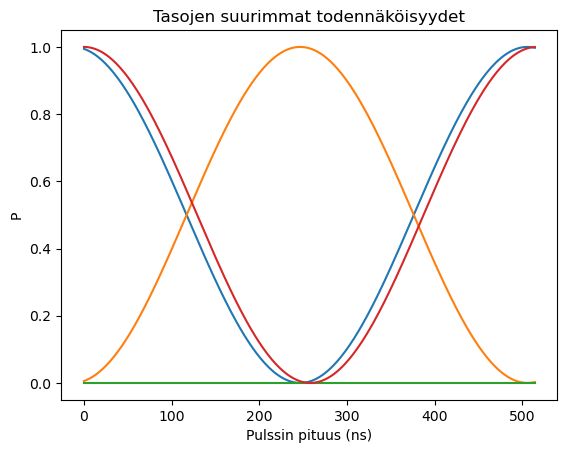

---------------------------------------------


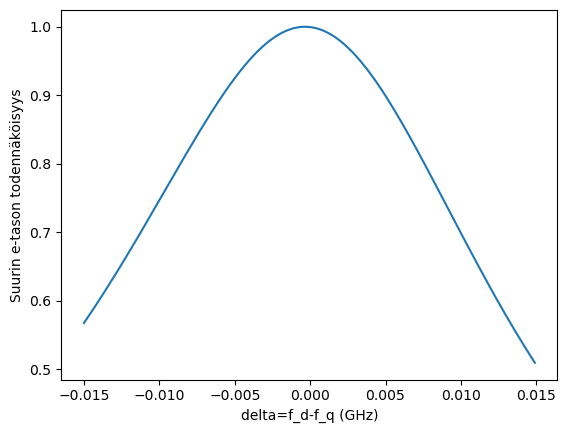

Amplitudi (GHz): 0.01622654761455188
AC-stark siirtymä (GHz): -0.0003
E-tason suurin todennäköisyys: 0.9999932430254037
Pulssin pituus (ns): 181.23067644620443
Rabi-taajuus (fourier):  0.0025823442762402246


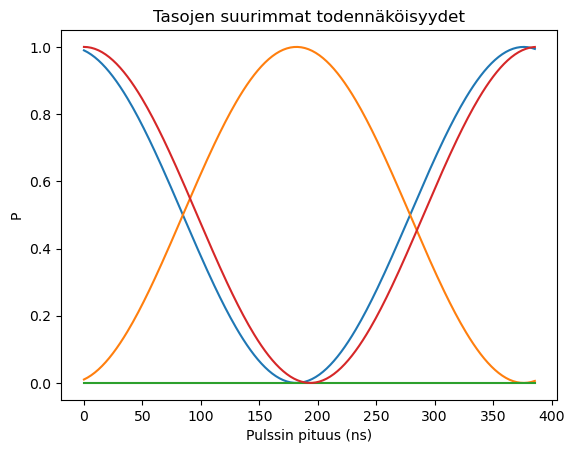

---------------------------------------------


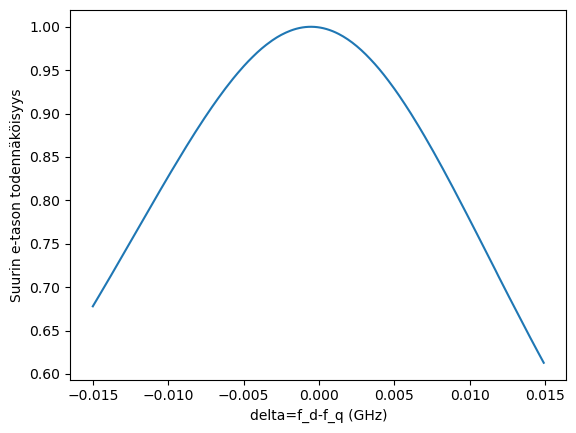

Amplitudi (GHz): 0.02028318451818985
AC-stark siirtymä (GHz): -0.0005
E-tason suurin todennäköisyys: 0.9999952161306321
Pulssin pituus (ns): 142.51319962648773
Rabi-taajuus (fourier):  0.003227771190357189


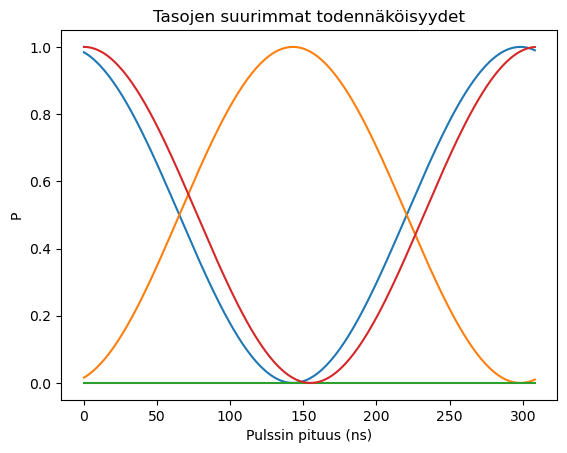

---------------------------------------------


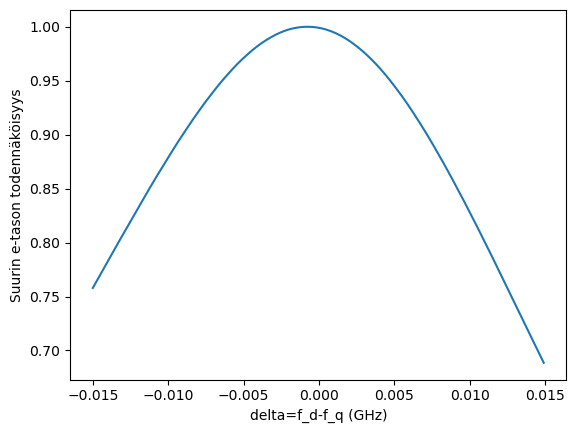

Amplitudi (GHz): 0.02433982142182782
AC-stark siirtymä (GHz): -0.0008
E-tason suurin todennäköisyys: 0.9999966561644156
Pulssin pituus (ns): 116.18783231046127
Rabi-taajuus (fourier):  0.0038722644966317343


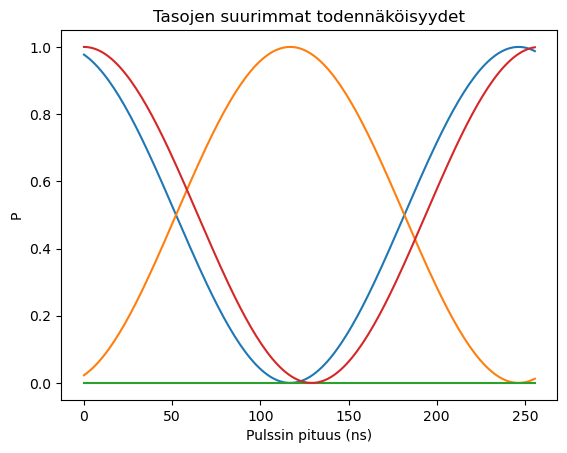

---------------------------------------------


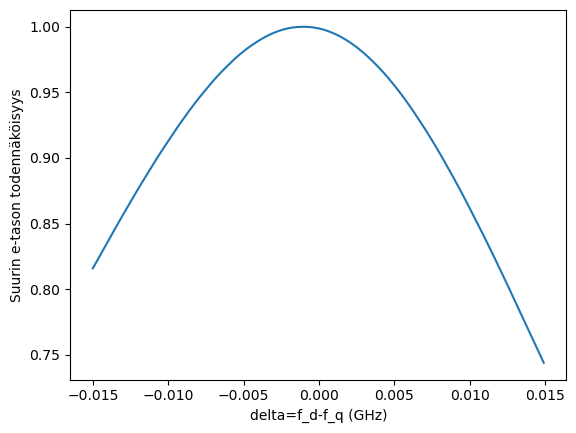

Amplitudi (GHz): 0.02839645832546579
AC-stark siirtymä (GHz): -0.001
E-tason suurin todennäköisyys: 0.9999971436989293
Pulssin pituus (ns): 99.15183957882971
Rabi-taajuus (fourier):  0.00451696753393906


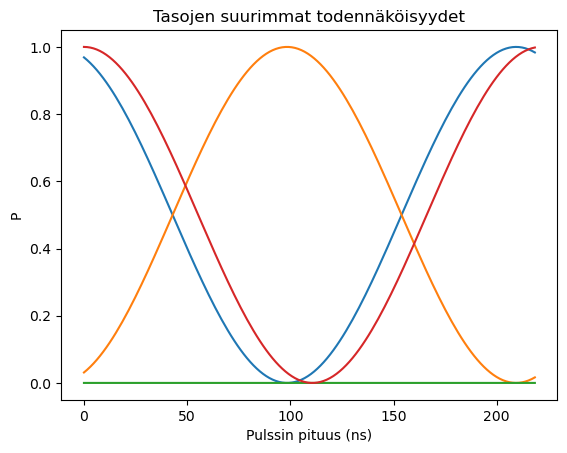

---------------------------------------------


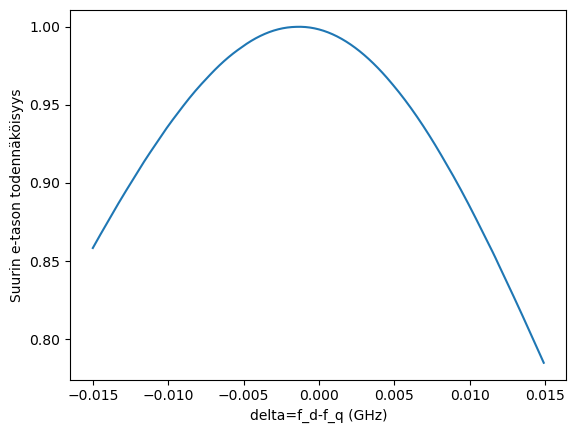

Amplitudi (GHz): 0.03245309522910376
AC-stark siirtymä (GHz): -0.0013
E-tason suurin todennäköisyys: 0.9999936656668084
Pulssin pituus (ns): 85.21491558071733
Rabi-taajuus (fourier):  0.005163415312935713


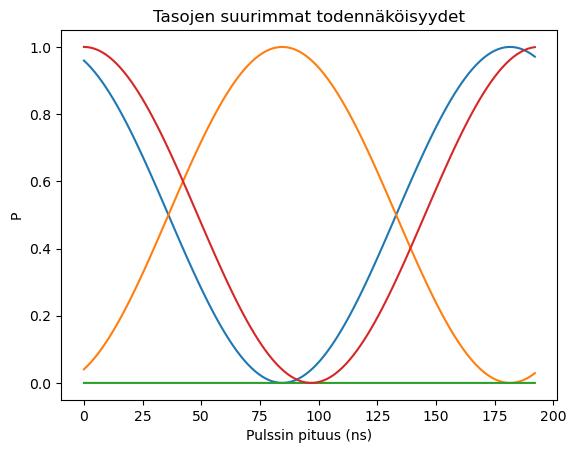

---------------------------------------------


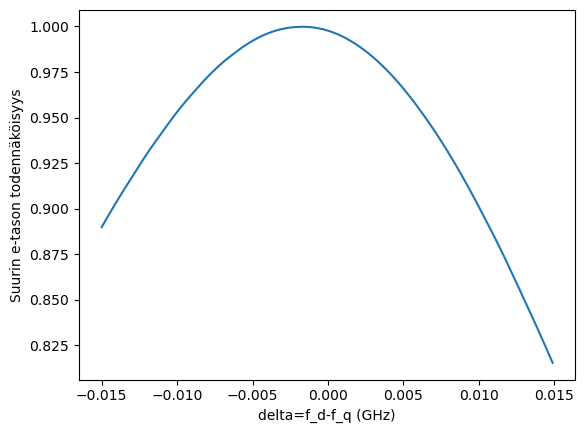

Amplitudi (GHz): 0.03650973213274173
AC-stark siirtymä (GHz): -0.0016
E-tason suurin todennäköisyys: 0.9999853556701639
Pulssin pituus (ns): 74.37488287074441
Rabi-taajuus (fourier):  0.005808993408047134


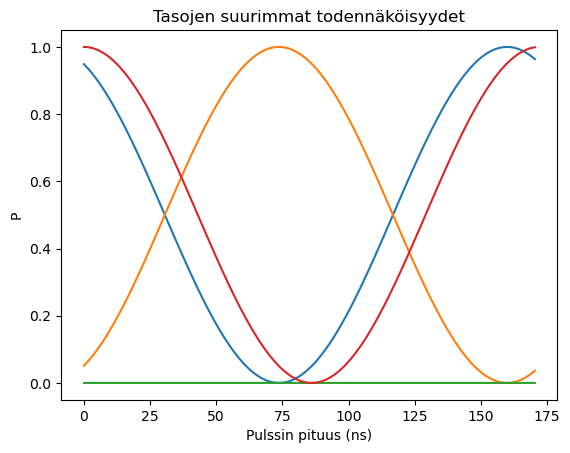

---------------------------------------------


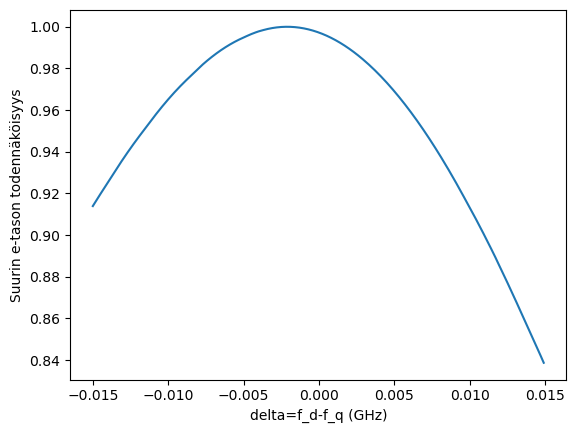

Amplitudi (GHz): 0.04056636903637971
AC-stark siirtymä (GHz): -0.0021
E-tason suurin todennäköisyys: 0.9999968512279866
Pulssin pituus (ns): 65.08604784550403
Rabi-taajuus (fourier):  0.006452995901624906


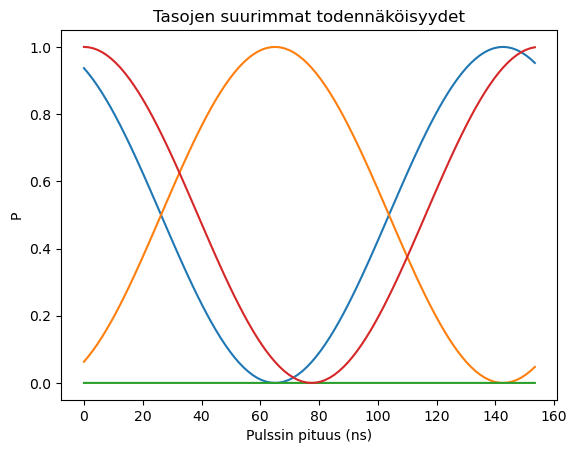

---------------------------------------------


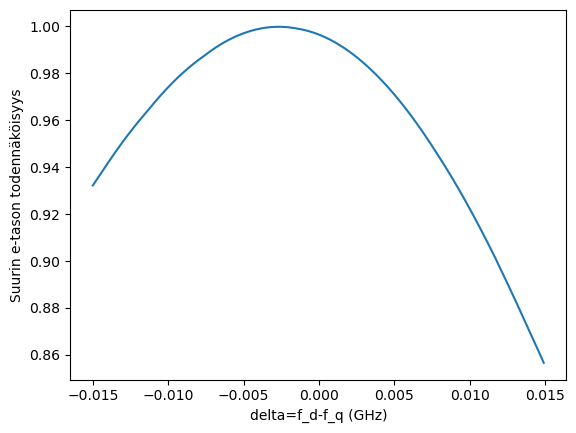

Amplitudi (GHz): 0.04462300594001767
AC-stark siirtymä (GHz): -0.0027
E-tason suurin todennäköisyys: 0.9999890492012206
Pulssin pituus (ns): 57.346195042409505
Rabi-taajuus (fourier):  0.007097954864649456


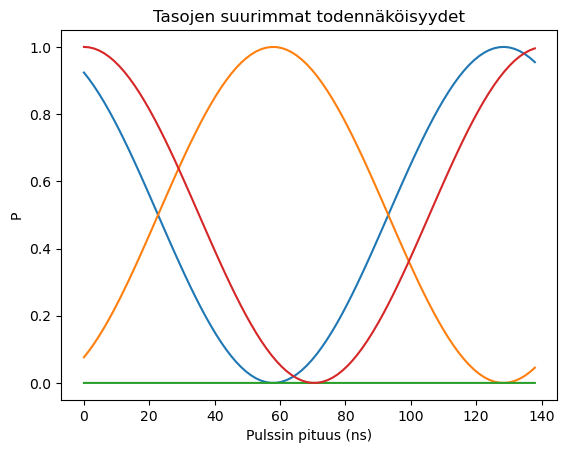

---------------------------------------------


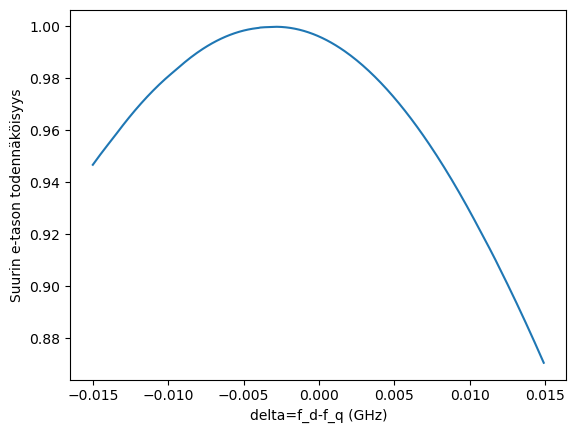

Amplitudi (GHz): 0.04867964284365564
AC-stark siirtymä (GHz): -0.0029
E-tason suurin todennäköisyys: 0.9999716064866611
Pulssin pituus (ns): 52.69910345005079
Rabi-taajuus (fourier):  0.007745165260600446


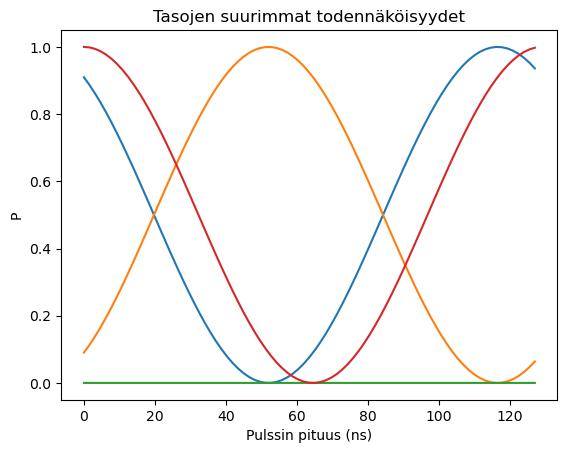

---------------------------------------------


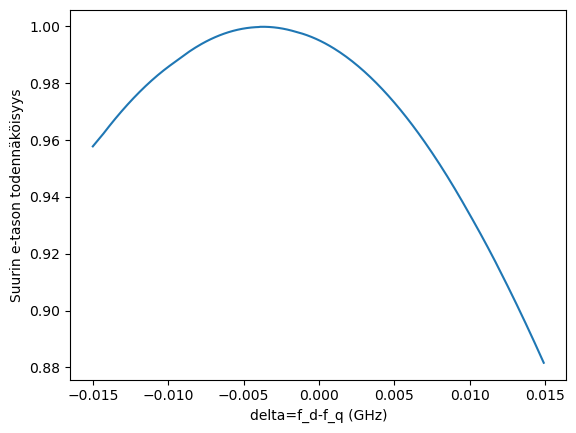

Amplitudi (GHz): 0.05273627974729361
AC-stark siirtymä (GHz): -0.0037
E-tason suurin todennäköisyys: 0.9999849337147871
Pulssin pituus (ns): 46.50838729963733
Rabi-taajuus (fourier):  0.008388100679499915


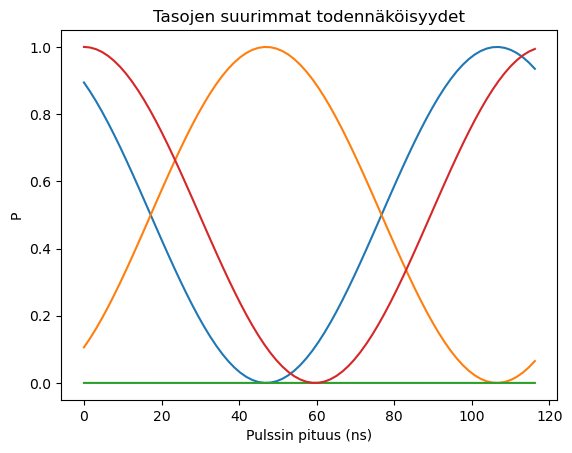

---------------------------------------------


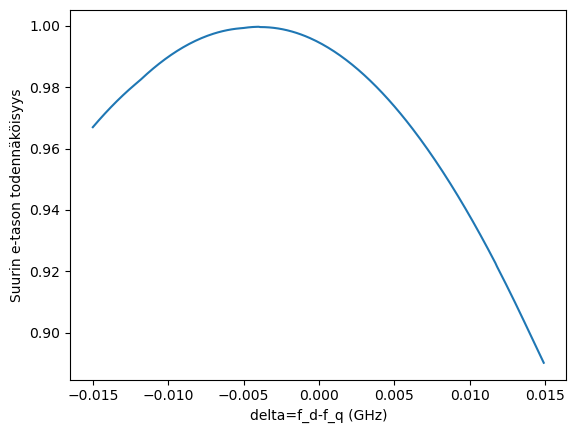

Amplitudi (GHz): 0.056792916650931585
AC-stark siirtymä (GHz): -0.004
E-tason suurin todennäköisyys: 0.9999772928821989
Pulssin pituus (ns): 43.411041448865134
Rabi-taajuus (fourier):  0.009033574170456807


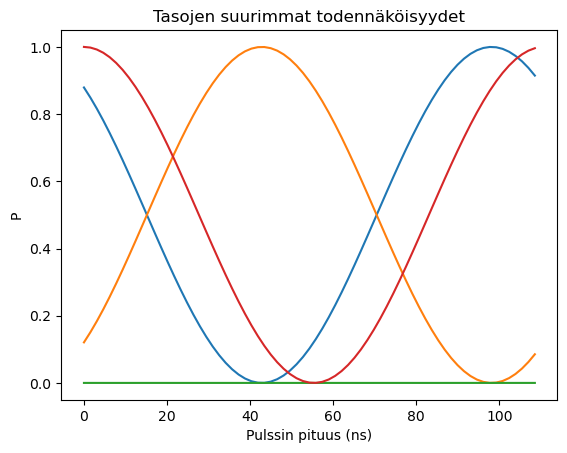

---------------------------------------------


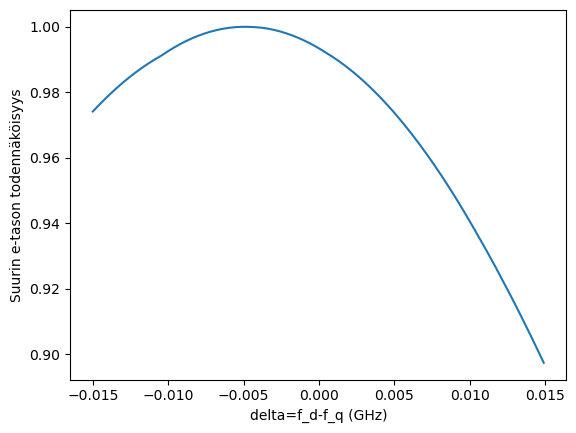

Amplitudi (GHz): 0.060849553554569544
AC-stark siirtymä (GHz): -0.0049
E-tason suurin todennäköisyys: 0.9999839687057775
Pulssin pituus (ns): 38.7684680460005
Rabi-taajuus (fourier):  0.009682491836664165


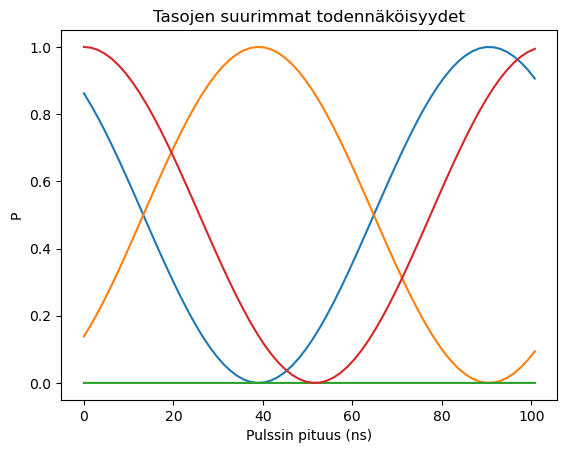

---------------------------------------------


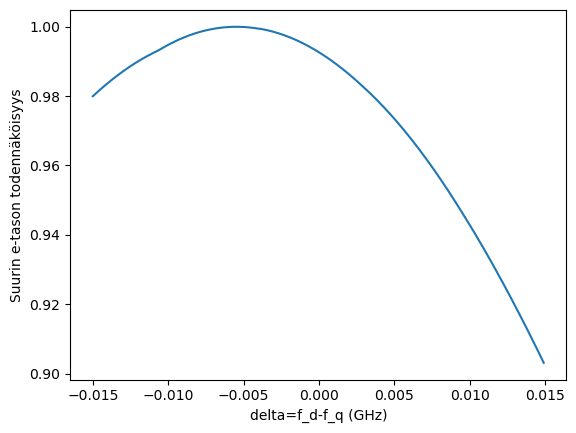

Amplitudi (GHz): 0.06490619045820752
AC-stark siirtymä (GHz): -0.0055
E-tason suurin todennäköisyys: 0.9999736734490048
Pulssin pituus (ns): 35.67227311803652
Rabi-taajuus (fourier):  0.010316135413695653


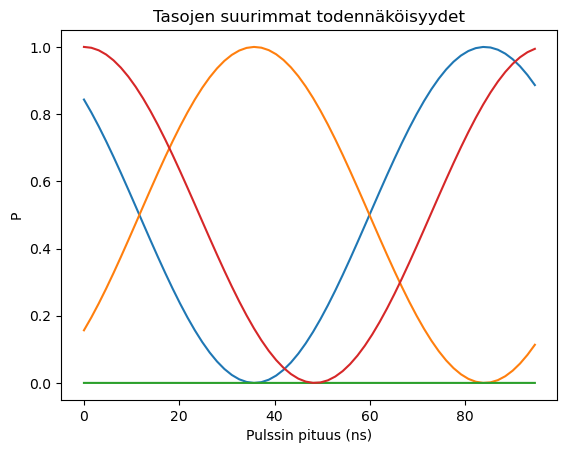

---------------------------------------------


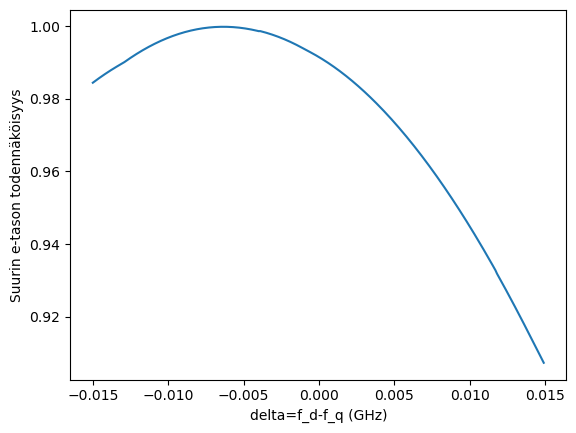

Amplitudi (GHz): 0.06896282736184549
AC-stark siirtymä (GHz): -0.0063
E-tason suurin todennäköisyys: 0.9998711837766348
Pulssin pituus (ns): 32.57676943669995
Rabi-taajuus (fourier):  0.010963114615671848


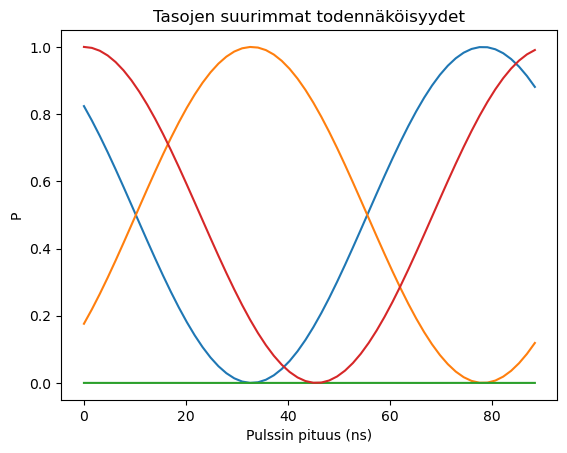

---------------------------------------------


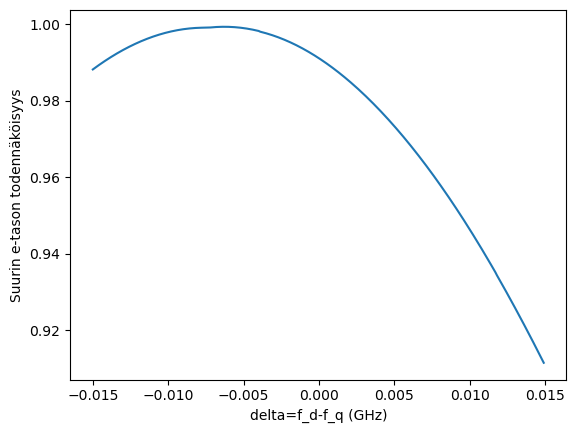

Amplitudi (GHz): 0.07301946426548346
AC-stark siirtymä (GHz): -0.0063
E-tason suurin todennäköisyys: 0.999903195815284
Pulssin pituus (ns): 31.025494701619
Rabi-taajuus (fourier):  0.011614975484711795


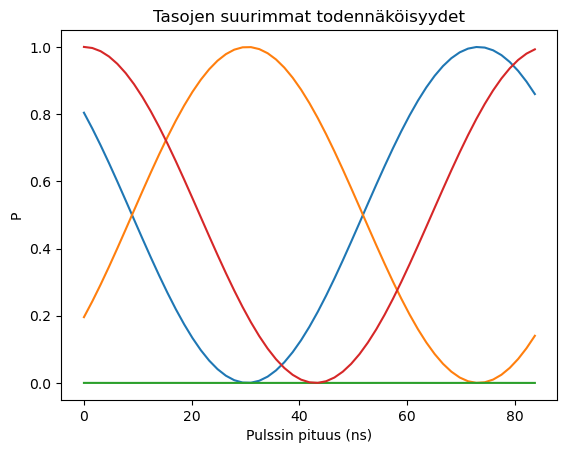

---------------------------------------------


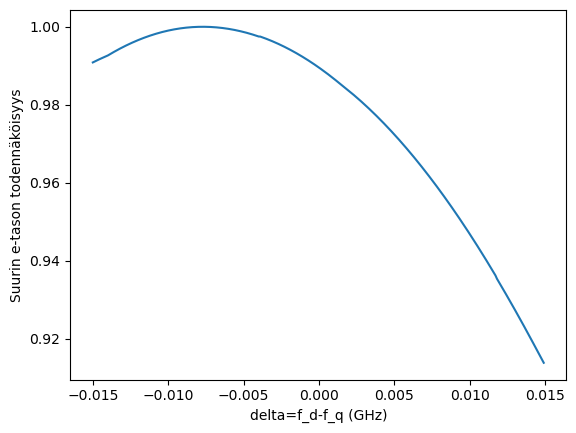

Amplitudi (GHz): 0.07707610116912145
AC-stark siirtymä (GHz): -0.0077
E-tason suurin todennäköisyys: 0.9999714860624935
Pulssin pituus (ns): 27.932600141932216
Rabi-taajuus (fourier):  0.012251108792417796


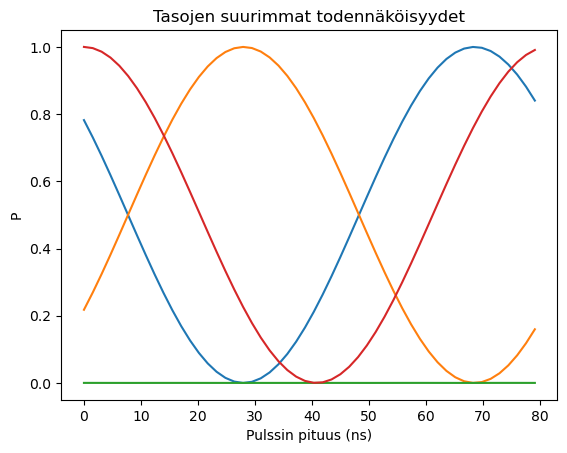

---------------------------------------------


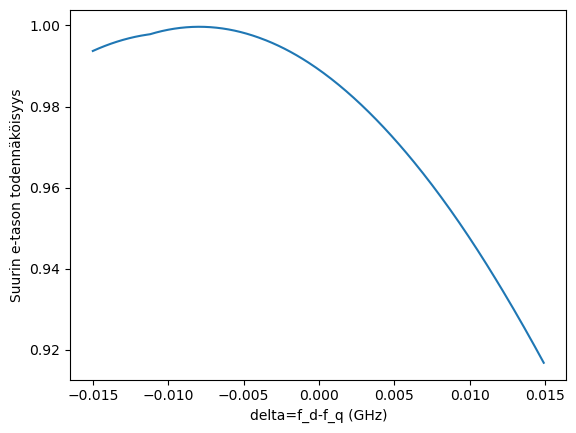

Amplitudi (GHz): 0.0811327380727594
AC-stark siirtymä (GHz): -0.0079
E-tason suurin todennäköisyys: 0.9999209739455901
Pulssin pituus (ns): 26.38209218437378
Rabi-taajuus (fourier):  0.012887529829851155


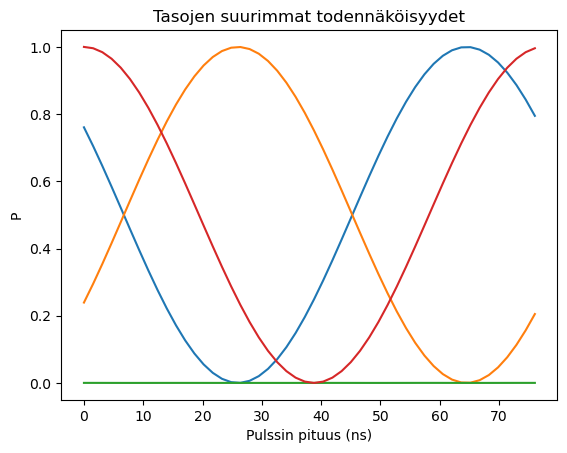

---------------------------------------------


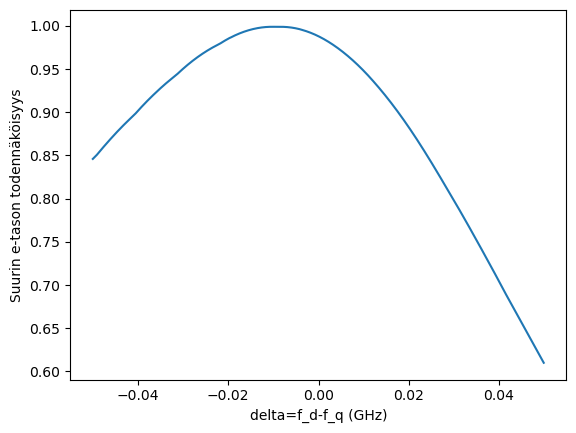

Amplitudi (GHz): 0.08518937497639738
AC-stark siirtymä (GHz): -0.0103
E-tason suurin todennäköisyys: 0.9990192110522229
Pulssin pituus (ns): 23.29212367931048
Rabi-taajuus (fourier):  0.013557779360613413


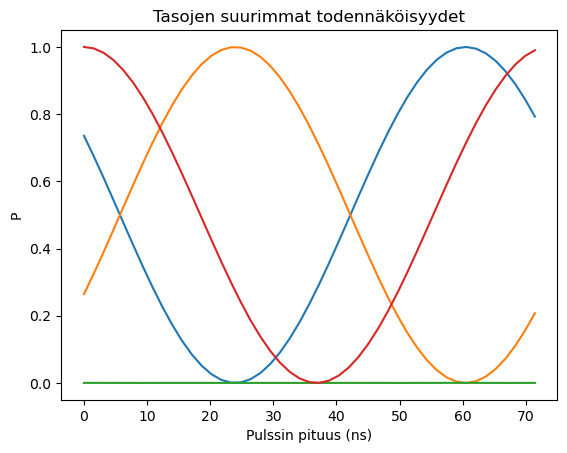

---------------------------------------------


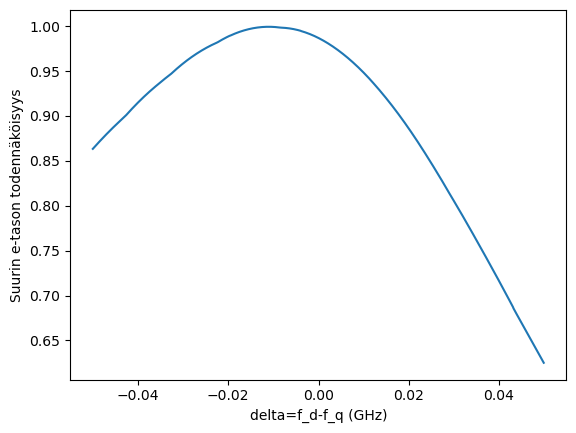

Amplitudi (GHz): 0.08924601188003535
AC-stark siirtymä (GHz): -0.011
E-tason suurin todennäköisyys: 0.9998822897580587
Pulssin pituus (ns): 21.743076898822423
Rabi-taajuus (fourier):  0.014182447382576492


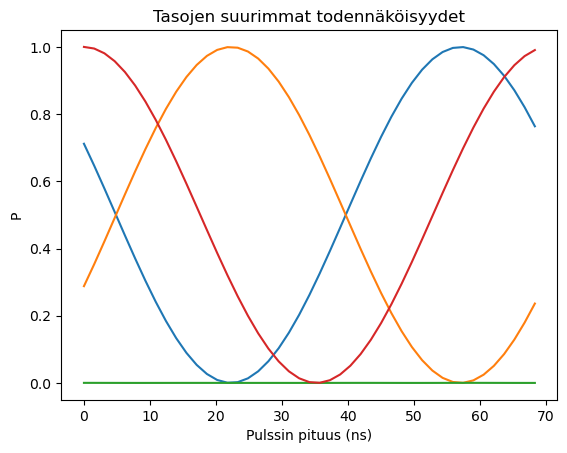

---------------------------------------------


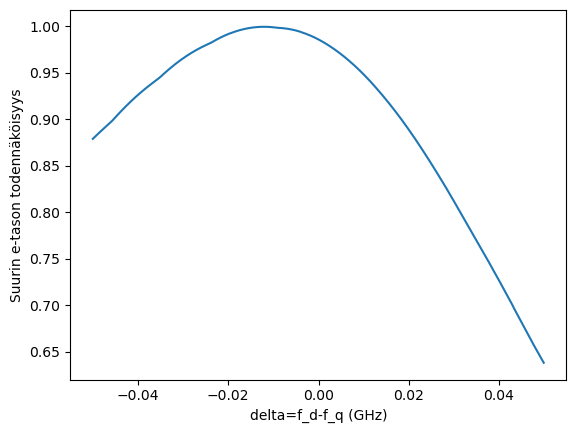

Amplitudi (GHz): 0.09330264878367331
AC-stark siirtymä (GHz): -0.0121
E-tason suurin todennäköisyys: 0.9998190927503989
Pulssin pituus (ns): 20.19549108820445
Rabi-taajuus (fourier):  0.014831982505335753


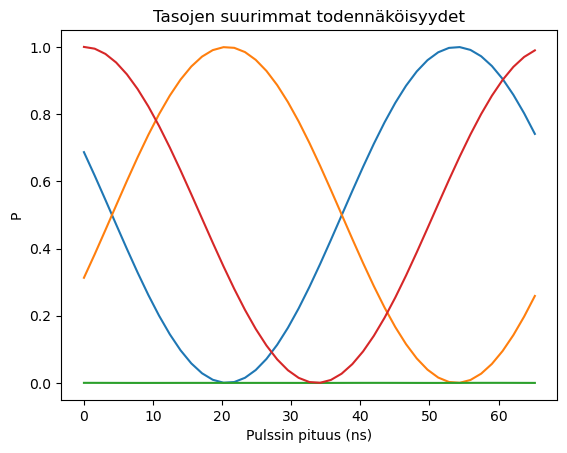

---------------------------------------------


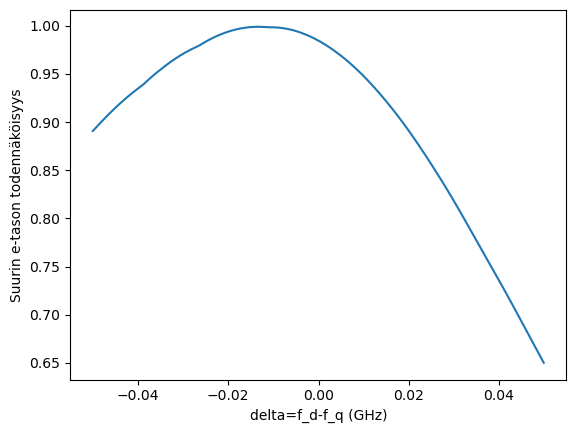

Amplitudi (GHz): 0.09735928568731128
AC-stark siirtymä (GHz): -0.0134
E-tason suurin todennäköisyys: 0.9997567220772654
Pulssin pituus (ns): 18.647985632084588
Rabi-taajuus (fourier):  0.015468777387152698


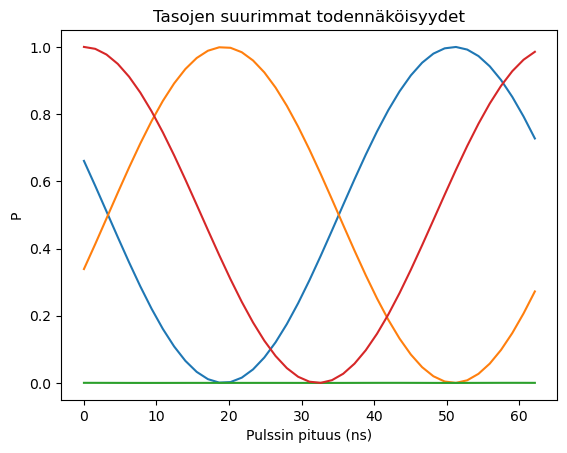

---------------------------------------------


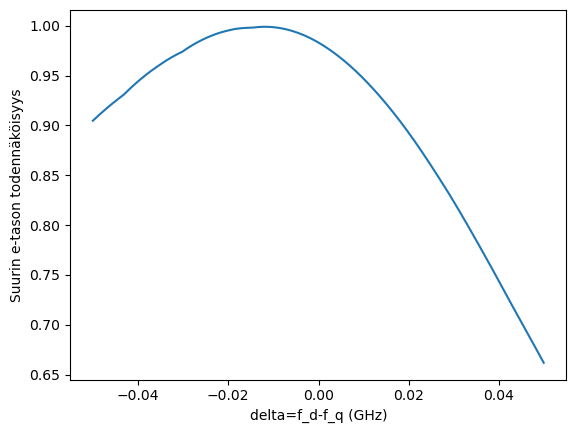

Amplitudi (GHz): 0.10141592259094925
AC-stark siirtymä (GHz): -0.0119
E-tason suurin todennäköisyys: 0.9995536614817223
Pulssin pituus (ns): 18.64106998364699
Rabi-taajuus (fourier):  0.016133831371433337


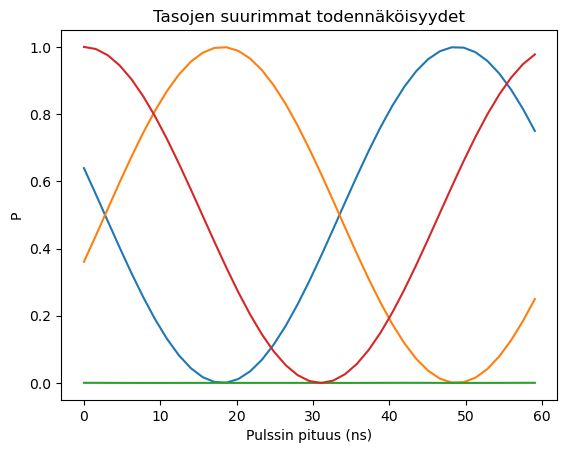

---------------------------------------------


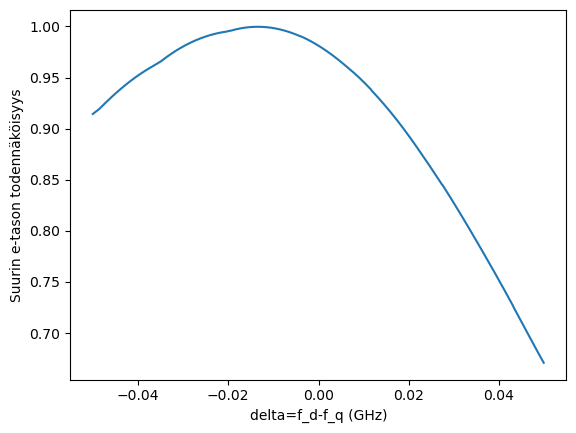

Amplitudi (GHz): 0.10547255949458723
AC-stark siirtymä (GHz): -0.0135
E-tason suurin todennäköisyys: 0.9998211814144715
Pulssin pituus (ns): 17.094409619616513
Rabi-taajuus (fourier):  0.016757427703417788


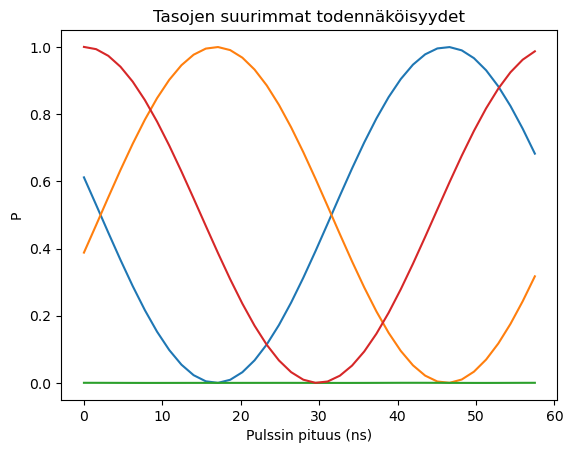

---------------------------------------------


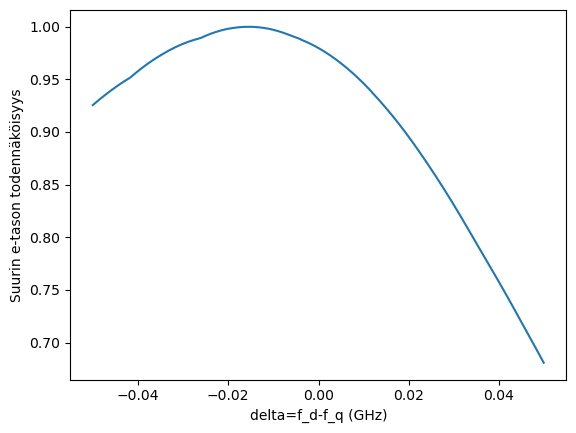

Amplitudi (GHz): 0.1095291963982252
AC-stark siirtymä (GHz): -0.0155
E-tason suurin todennäköisyys: 0.9998187015426452
Pulssin pituus (ns): 15.548063470760537
Rabi-taajuus (fourier):  0.017429997667345775


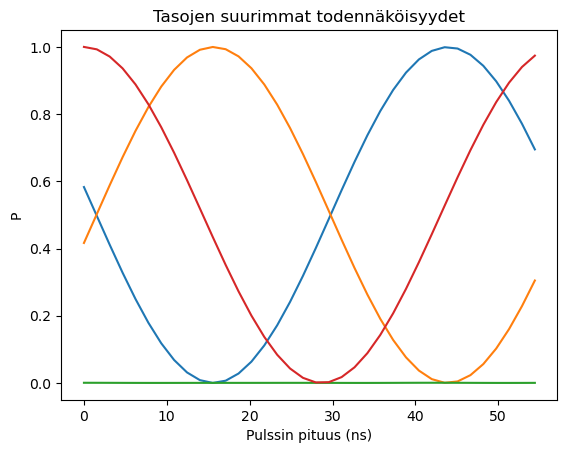

---------------------------------------------


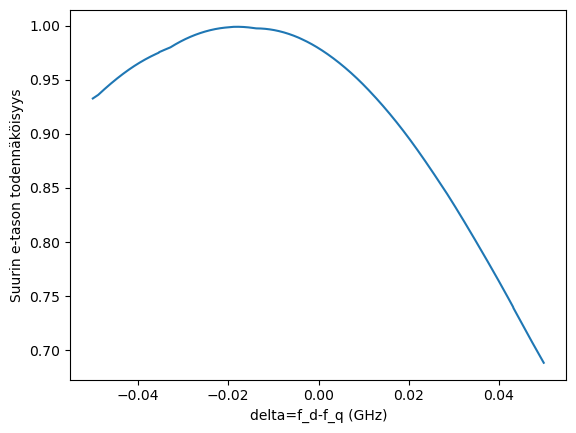

Amplitudi (GHz): 0.11358583330186316
AC-stark siirtymä (GHz): -0.0181
E-tason suurin todennäköisyys: 0.9995747647822816
Pulssin pituus (ns): 14.002265947768473
Rabi-taajuus (fourier):  0.018054862670590463


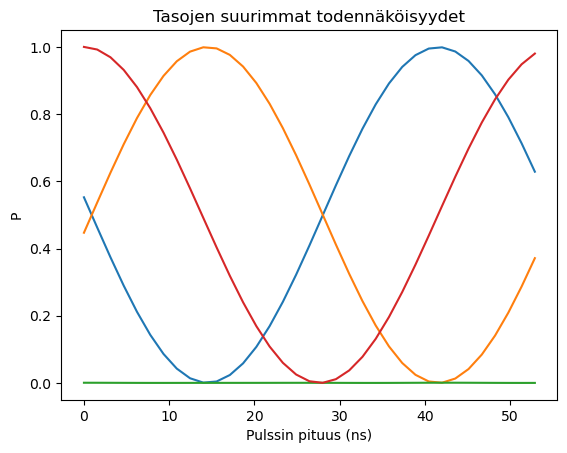

---------------------------------------------


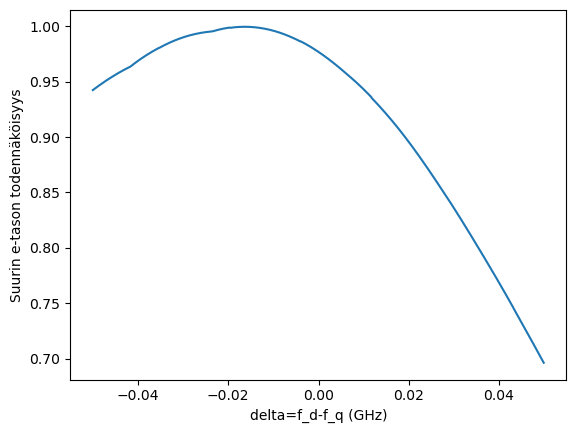

Amplitudi (GHz): 0.11764247020550113
AC-stark siirtymä (GHz): -0.0163
E-tason suurin todennäköisyys: 0.9997503663811693
Pulssin pituus (ns): 13.996027834634077
Rabi-taajuus (fourier):  0.01869301133635423


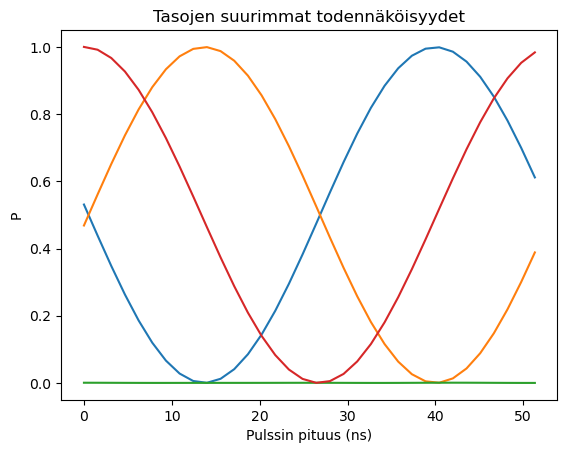

---------------------------------------------


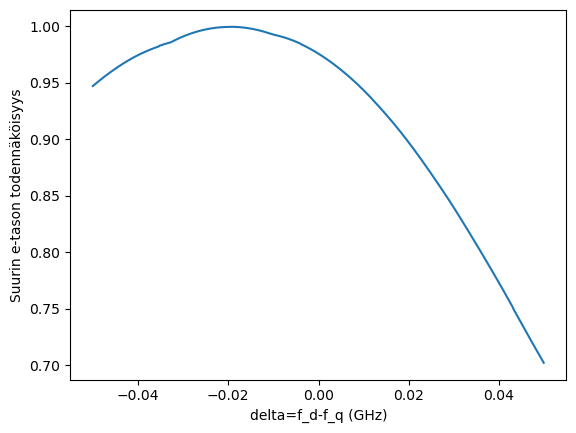

Amplitudi (GHz): 0.1216991071091391
AC-stark siirtymä (GHz): -0.0195
E-tason suurin todennäköisyys: 0.9996829766405739
Pulssin pituus (ns): 12.450774808290783
Rabi-taajuus (fourier):  0.01935332211303288


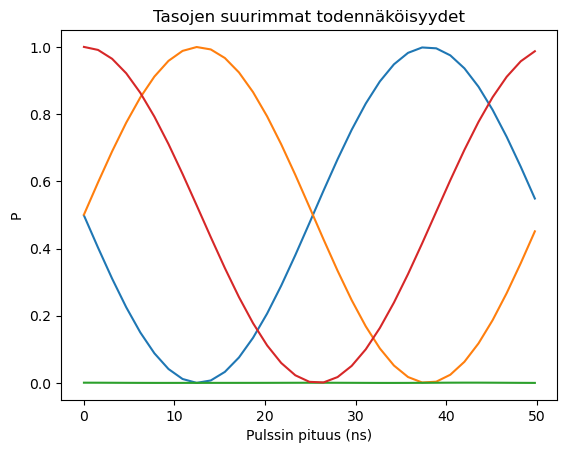

---------------------------------------------


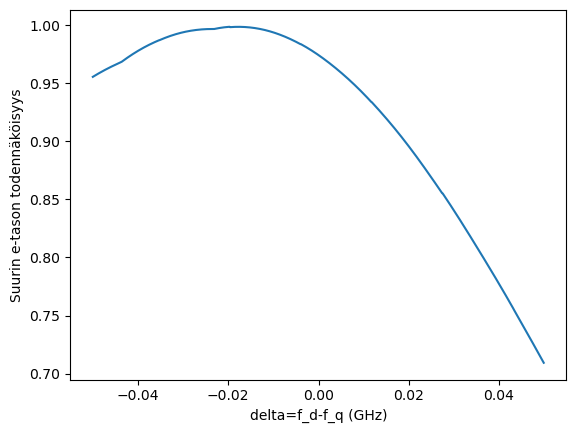

Amplitudi (GHz): 0.12575574401277706
AC-stark siirtymä (GHz): -0.0197
E-tason suurin todennäköisyys: 0.9997047357904287
Pulssin pituus (ns): 12.45139165096658
Rabi-taajuus (fourier):  0.01995336842124451


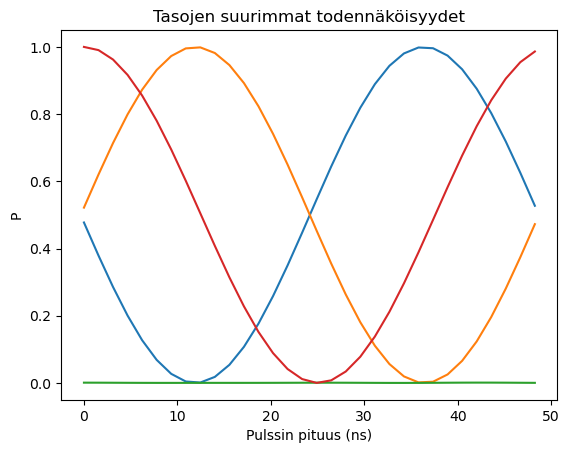

---------------------------------------------


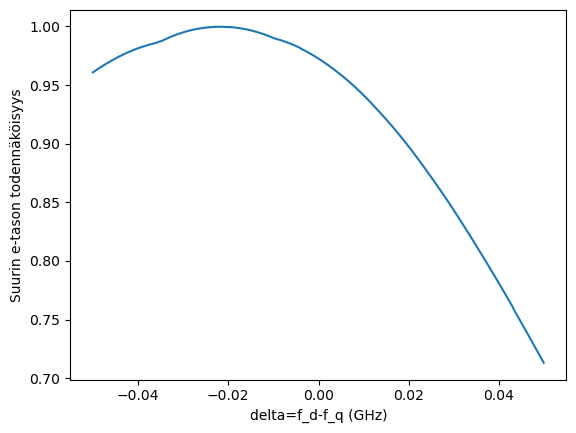

Amplitudi (GHz): 0.12981238091641503
AC-stark siirtymä (GHz): -0.0219
E-tason suurin todennäköisyys: 0.9997159752422933
Pulssin pituus (ns): 10.900908336947552
Rabi-taajuus (fourier):  0.02064785602216306


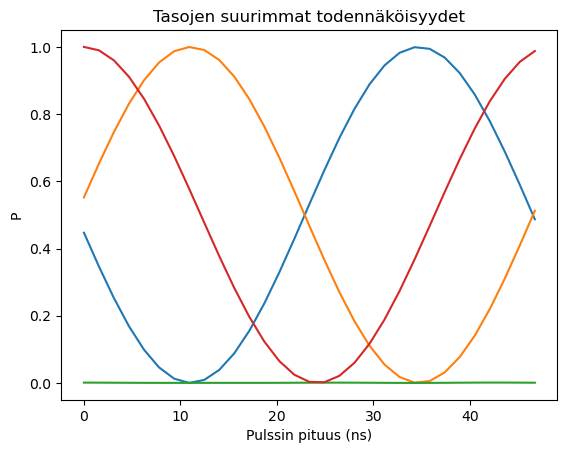

---------------------------------------------


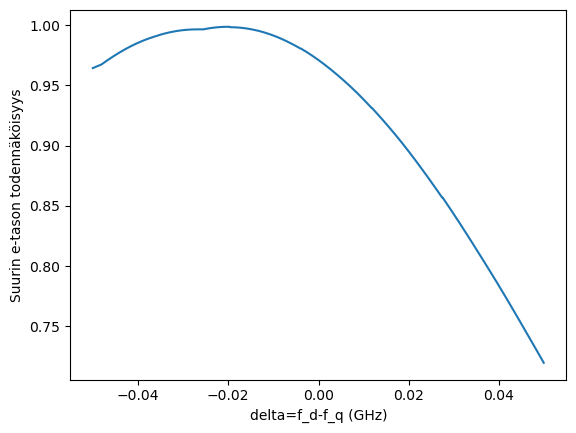

Amplitudi (GHz): 0.133869017820053
AC-stark siirtymä (GHz): -0.0201
E-tason suurin todennäköisyys: 0.9994818714508915
Pulssin pituus (ns): 10.896047329733964
Rabi-taajuus (fourier):  0.021272675535987967


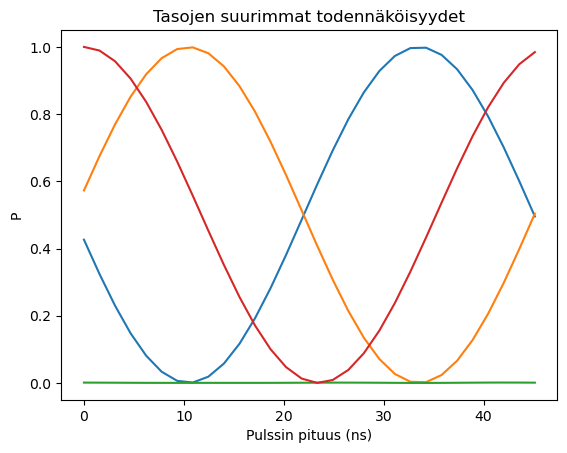

---------------------------------------------


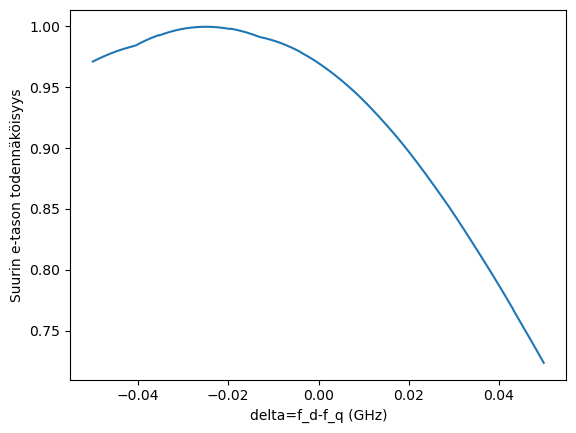

Amplitudi (GHz): 0.13792565472369098
AC-stark siirtymä (GHz): -0.0249
E-tason suurin todennäköisyys: 0.999588310271288
Pulssin pituus (ns): 9.350588280961578
Rabi-taajuus (fourier):  0.021900029264846264


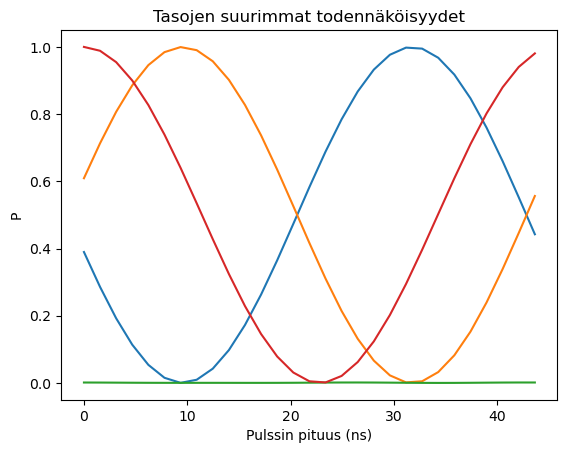

---------------------------------------------


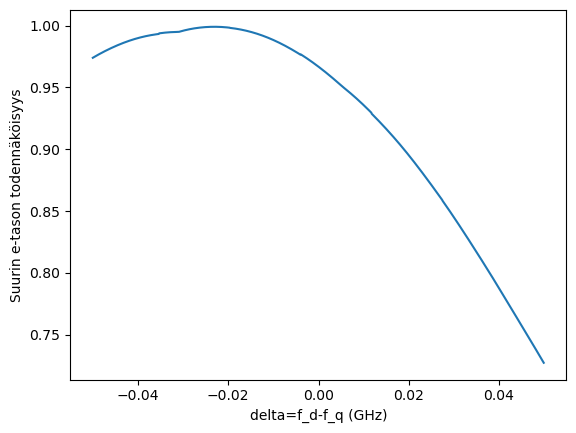

Amplitudi (GHz): 0.14198229162732895
AC-stark siirtymä (GHz): -0.0231
E-tason suurin todennäköisyys: 0.999472571114853
Pulssin pituus (ns): 9.346415501758653
Rabi-taajuus (fourier):  0.022524818819563537


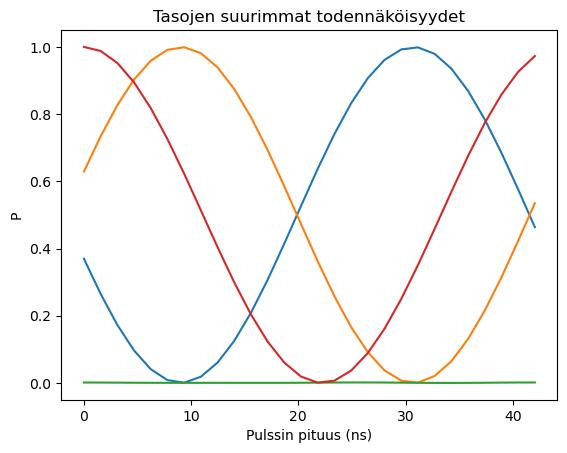

---------------------------------------------


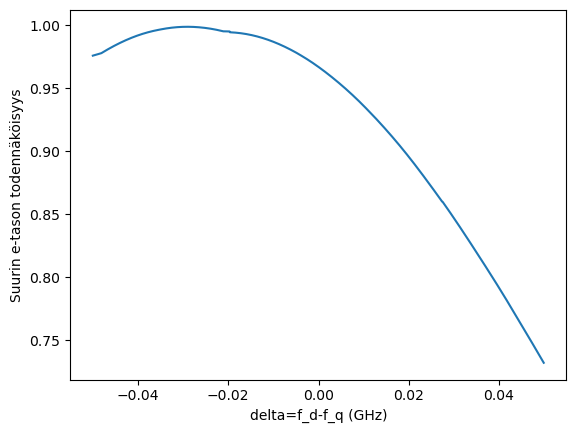

Amplitudi (GHz): 0.14603892853096692
AC-stark siirtymä (GHz): -0.0291
E-tason suurin todennäköisyys: 0.9993432935415308
Pulssin pituus (ns): 7.800282725533994
Rabi-taajuus (fourier):  0.023224724880398895


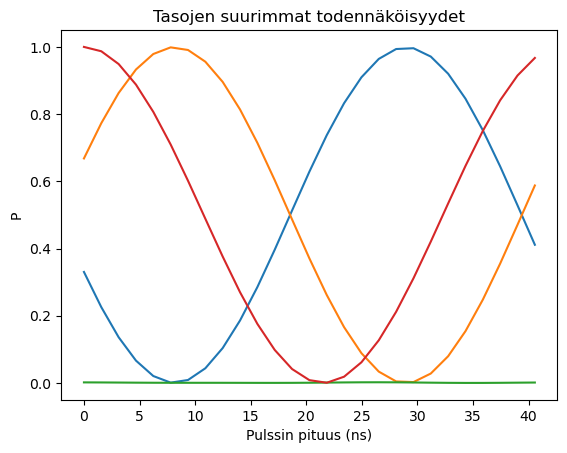

---------------------------------------------


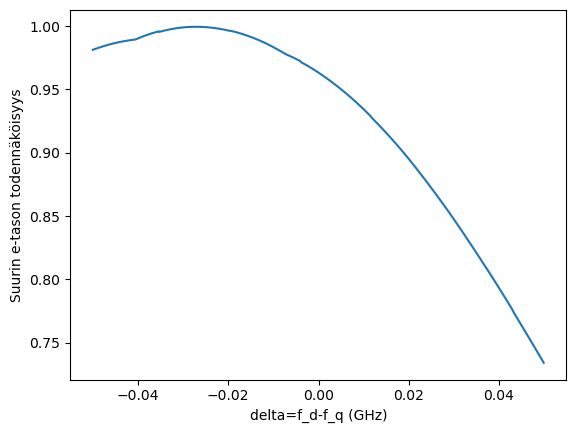

Amplitudi (GHz): 0.1500955654346049
AC-stark siirtymä (GHz): -0.0271
E-tason suurin todennäköisyys: 0.9995842203780076
Pulssin pituus (ns): 7.796411172592767
Rabi-taajuus (fourier):  0.023840918832163317


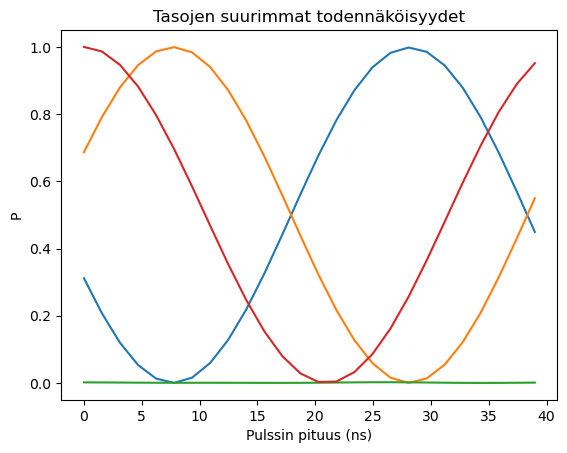

---------------------------------------------


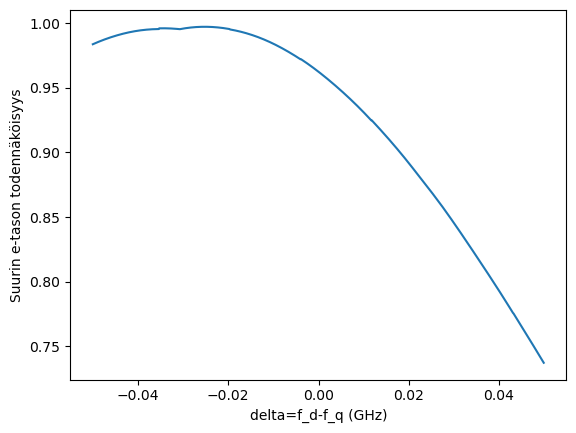

Amplitudi (GHz): 0.15415220233824287
AC-stark siirtymä (GHz): -0.0252
E-tason suurin todennäköisyys: 0.9989469206756212
Pulssin pituus (ns): 7.792736755360896
Rabi-taajuus (fourier):  0.024489431716681984


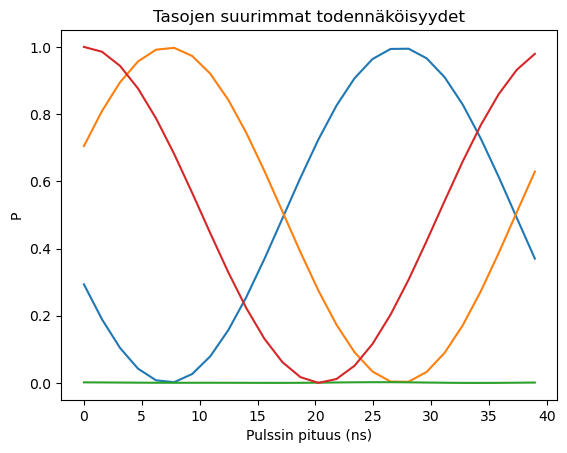

---------------------------------------------


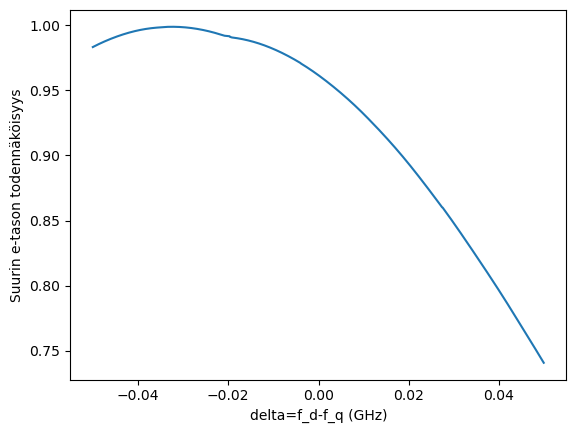

Amplitudi (GHz): 0.15820883924188084
AC-stark siirtymä (GHz): -0.0324
E-tason suurin todennäköisyys: 0.9993343066280347
Pulssin pituus (ns): 6.245343360873703
Rabi-taajuus (fourier):  0.02511675276026691


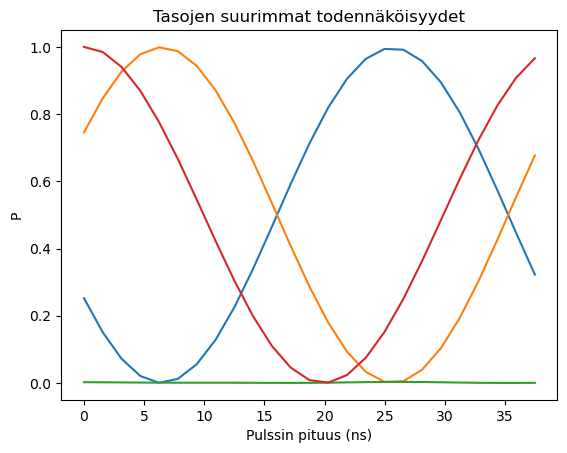

---------------------------------------------


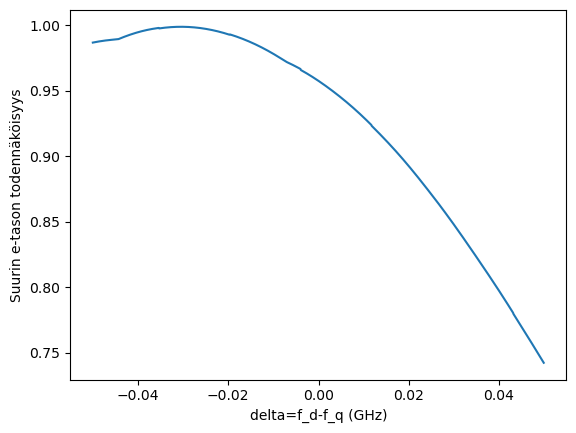

Amplitudi (GHz): 0.1622654761455188
AC-stark siirtymä (GHz): -0.0304
E-tason suurin todennäköisyys: 0.9991457305776448
Pulssin pituus (ns): 6.242241038029645
Rabi-taajuus (fourier):  0.025734759247911243


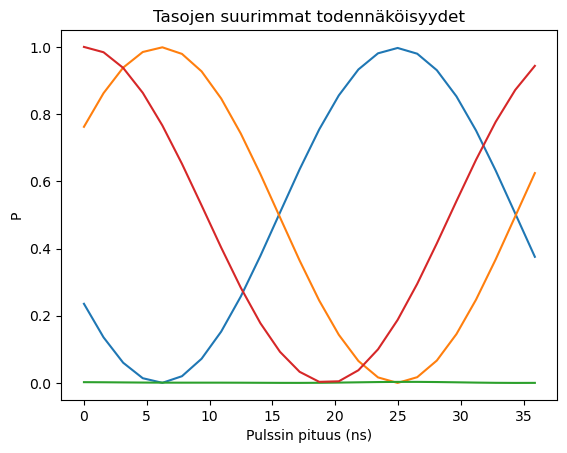

---------------------------------------------


In [6]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.001
max_range = 0.040
N_data=40
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    if i < 20:
        params=find_params(qubit, A, evolution_eigenbasis,A, [-150,150],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,A, [-500,500],10000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = qubit.frequency+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=10
    vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,A/m)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 2*np.pi/(f_d_opt)
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.00405663690363797), np.float64(0.00811327380727594), np.float64(0.01216991071091391), np.float64(0.01622654761455188), np.float64(0.02028318451818985), np.float64(0.02433982142182782), np.float64(0.02839645832546579), np.float64(0.03245309522910376), np.float64(0.03650973213274173), np.float64(0.04056636903637971), np.float64(0.04462300594001767), np.float64(0.04867964284365564), np.float64(0.05273627974729361), np.float64(0.056792916650931585), np.float64(0.060849553554569544), np.float64(0.06490619045820752), np.float64(0.06896282736184549), np.float64(0.07301946426548346), np.float64(0.07707610116912145), np.float64(0.0811327380727594), np.float64(0.08518937497639738), np.float64(0.08924601188003535), np.float64(0.09330264878367331), np.float64(0.09735928568731128), np.float64(0.10141592259094925), np.float64(0.10547255949458723), np.float64(0.1095291963982252), np.float64(0.11358583330186316), np.float64(0.11764247020550113), np.float64(0.1216991071091391), np.float64

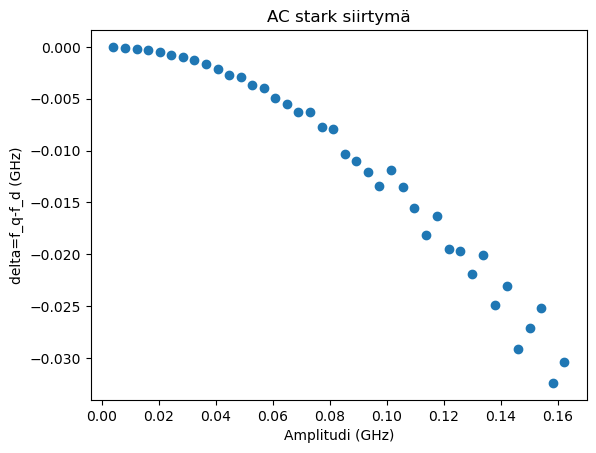

[0.0, -0.0001, -0.0002, -0.0003, -0.0005, -0.0008, -0.001, -0.0013, -0.0016, -0.0021, -0.0027, -0.0029, -0.0037, -0.004, -0.0049, -0.0055, -0.0063, -0.0063, -0.0077, -0.0079, -0.0103, -0.011, -0.0121, -0.0134, -0.0119, -0.0135, -0.0155, -0.0181, -0.0163, -0.0195, -0.0197, -0.0219, -0.0201, -0.0249, -0.0231, -0.0291, -0.0271, -0.0252, -0.0324, -0.0304]


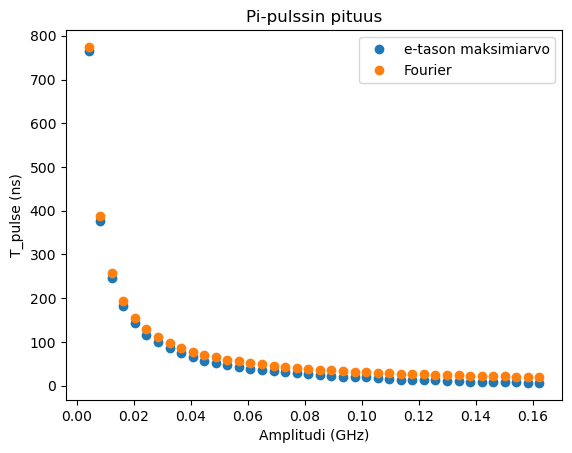

[np.float64(765.1396009741865), np.float64(376.3836163490506), np.float64(246.28177081852022), np.float64(181.23067644620443), np.float64(142.51319962648773), np.float64(116.18783231046127), np.float64(99.15183957882971), np.float64(85.21491558071733), np.float64(74.37488287074441), np.float64(65.08604784550403), np.float64(57.346195042409505), np.float64(52.69910345005079), np.float64(46.50838729963733), np.float64(43.411041448865134), np.float64(38.7684680460005), np.float64(35.67227311803652), np.float64(32.57676943669995), np.float64(31.025494701619), np.float64(27.932600141932216), np.float64(26.38209218437378), np.float64(23.29212367931048), np.float64(21.743076898822423), np.float64(20.19549108820445), np.float64(18.647985632084588), np.float64(18.64106998364699), np.float64(17.094409619616513), np.float64(15.548063470760537), np.float64(14.002265947768473), np.float64(13.996027834634077), np.float64(12.450774808290783), np.float64(12.45139165096658), np.float64(10.9009083369475

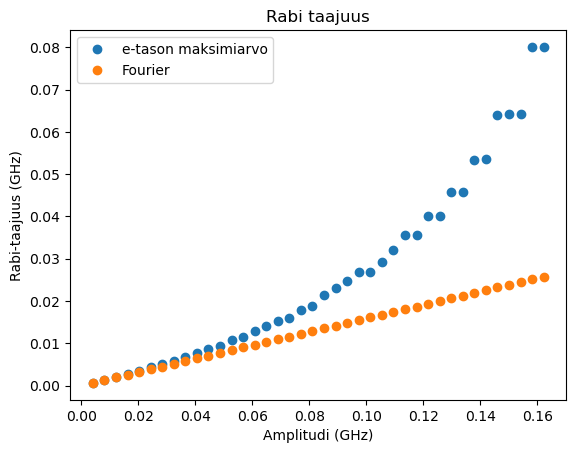

[np.float64(0.0006455692586171219), np.float64(0.001291235800097349), np.float64(0.0019364186699291099), np.float64(0.0025823442762402246), np.float64(0.003227771190357189), np.float64(0.0038722644966317343), np.float64(0.00451696753393906), np.float64(0.005163415312935713), np.float64(0.005808993408047134), np.float64(0.006452995901624906), np.float64(0.007097954864649456), np.float64(0.007745165260600446), np.float64(0.008388100679499915), np.float64(0.009033574170456807), np.float64(0.009682491836664165), np.float64(0.010316135413695653), np.float64(0.010963114615671848), np.float64(0.011614975484711795), np.float64(0.012251108792417796), np.float64(0.012887529829851155), np.float64(0.013557779360613413), np.float64(0.014182447382576492), np.float64(0.014831982505335753), np.float64(0.015468777387152698), np.float64(0.016133831371433337), np.float64(0.016757427703417788), np.float64(0.017429997667345775), np.float64(0.018054862670590463), np.float64(0.01869301133635423), np.float64(

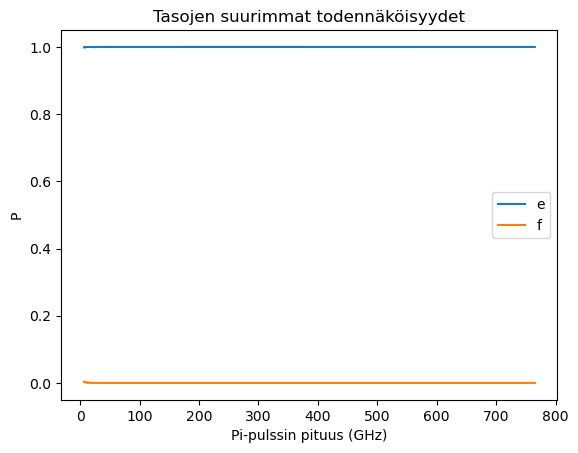

[np.float64(0.9999721629125684), np.float64(0.999996613059079), np.float64(0.9999994797567014), np.float64(0.9999932430254037), np.float64(0.9999952161306321), np.float64(0.9999966561644156), np.float64(0.9999971436989293), np.float64(0.9999936656668084), np.float64(0.9999853556701639), np.float64(0.9999968512279866), np.float64(0.9999890492012206), np.float64(0.9999716064866611), np.float64(0.9999849337147871), np.float64(0.9999772928821989), np.float64(0.9999839687057775), np.float64(0.9999736734490048), np.float64(0.9998711837766348), np.float64(0.999903195815284), np.float64(0.9999714860624935), np.float64(0.9999209739455901), np.float64(0.9990192110522229), np.float64(0.9998822897580587), np.float64(0.9998190927503989), np.float64(0.9997567220772654), np.float64(0.9995536614817223), np.float64(0.9998211814144715), np.float64(0.9998187015426452), np.float64(0.9995747647822816), np.float64(0.9997503663811693), np.float64(0.9996829766405739), np.float64(0.9997047357904287), np.float6

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=f_q-f_d (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)